# min and max

Saved to minimax_graph.png


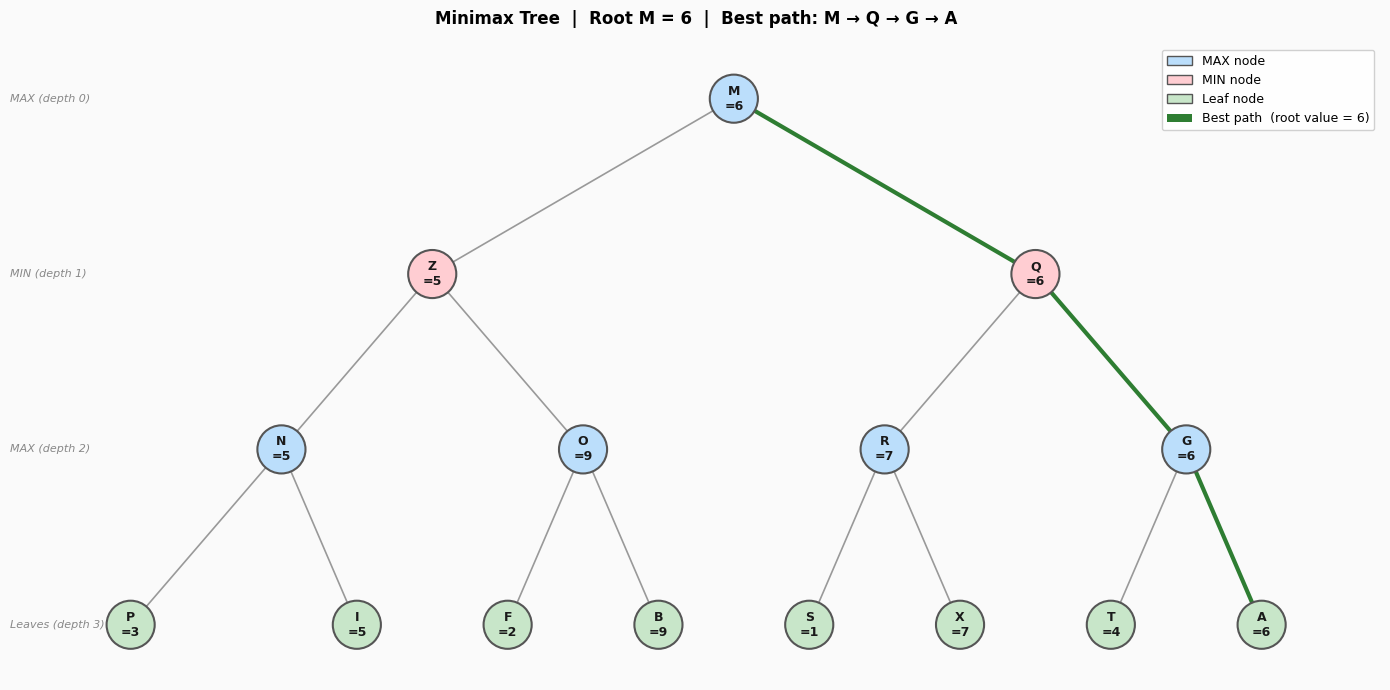

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ─── Tree structure ───────────────────────────────────────────────────────────
TREE = {
    'M': ['Z', 'Q'],
    'Z': ['N', 'O'],
    'Q': ['R', 'G'],
    'N': ['P', 'I'],
    'O': ['F', 'B'],
    'R': ['S', 'X'],
    'G': ['T', 'A'],
    'P': [], 'I': [], 'F': [], 'B': [],
    'S': [], 'X': [], 'T': [], 'A': []
}

LEAF_VALUES = {
    'P': 3, 'I': 5, 'F': 2, 'B': 9,
    'S': 1, 'X': 7, 'T': 4, 'A': 6
}

DEPTHS = {
    'M': 0,
    'Z': 1, 'Q': 1,
    'N': 2, 'O': 2, 'R': 2, 'G': 2,
    'P': 3, 'I': 3, 'F': 3, 'B': 3,
    'S': 3, 'X': 3, 'T': 3, 'A': 3,
}


# ─── Minimax function (no class) ─────────────────────────────────────────────
def minimax(node, depth, is_maximizing, tree, leaf_values):
    children = tree.get(node, [])
    if not children:
        return leaf_values[node], None
    child_results = [
        minimax(c, depth + 1, not is_maximizing, tree, leaf_values)
        for c in children
    ]
    child_vals = [r[0] for r in child_results]
    best_val   = max(child_vals) if is_maximizing else min(child_vals)
    best_child = children[child_vals.index(best_val)]
    return best_val, best_child


# ─── Trace best path ──────────────────────────────────────────────────────────
def get_best_path(start, is_maximizing, tree, leaf_values):
    path_edges = []
    node, is_max = start, is_maximizing
    while tree.get(node):
        _, next_node = minimax(node, 0, is_max, tree, leaf_values)
        path_edges.append((node, next_node))
        node, is_max = next_node, not is_max
    return path_edges


# ─── Build graph ──────────────────────────────────────────────────────────────
G = nx.DiGraph()
for parent, children in TREE.items():
    for child in children:
        G.add_edge(parent, child)

# ─── Node positions (fixed layout matching your screenshot) ──────────────────
# Depth 0: M (center)
# Depth 1: Z (left), Q (right)
# Depth 2: N O R G spread
# Depth 3: leaves spread evenly
pos = {
    'M': (4.0, 3.0),
    'Z': (2.0, 2.0),
    'Q': (6.0, 2.0),
    'N': (1.0, 1.0),
    'O': (3.0, 1.0),
    'R': (5.0, 1.0),
    'G': (7.0, 1.0),
    'P': (0.0, 0.0),
    'I': (1.5, 0.0),
    'F': (2.5, 0.0),
    'B': (3.5, 0.0),
    'S': (4.5, 0.0),
    'X': (5.5, 0.0),
    'T': (6.5, 0.0),
    'A': (7.5, 0.0),
}

# ─── Run minimax ──────────────────────────────────────────────────────────────
root_val, root_best = minimax('M', 0, True, TREE, LEAF_VALUES)
best_edges          = get_best_path('M', True, TREE, LEAF_VALUES)
best_edge_set       = set(best_edges)

# ─── Node values for labels ───────────────────────────────────────────────────
node_vals = {}
for node in TREE:
    d      = DEPTHS[node]
    is_max = (d % 2 == 0)
    val, _ = minimax(node, d, is_max, TREE, LEAF_VALUES)
    node_vals[node] = val

# ─── Colors ───────────────────────────────────────────────────────────────────
node_colors = []
for node in G.nodes():
    d = DEPTHS[node]
    if d == 3:                    # leaf
        node_colors.append('#c8e6c9')   # green
    elif d % 2 == 0:              # MAX
        node_colors.append('#bbdefb')   # blue
    else:                         # MIN
        node_colors.append('#ffcdd2')   # red

edge_colors = []
edge_widths = []
for u, v in G.edges():
    if (u, v) in best_edge_set:
        edge_colors.append('#2e7d32')
        edge_widths.append(3.0)
    else:
        edge_colors.append('#999999')
        edge_widths.append(1.2)

# ─── Draw ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=edge_colors,
    width=edge_widths,
    arrows=False
)

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=1200,
    linewidths=1.5,
    edgecolors='#555555'
)

# Node labels: name + value
labels = {n: f"{n}\n={node_vals[n]}" for n in G.nodes()}
nx.draw_networkx_labels(
    G, pos, labels=labels, ax=ax,
    font_size=9, font_weight='bold', font_color='#1a1a1a'
)

# ─── Depth annotations on left ───────────────────────────────────────────────
depth_labels = {0: 'MAX (depth 0)', 1: 'MIN (depth 1)',
                2: 'MAX (depth 2)', 3: 'Leaves (depth 3)'}
y_positions  = {0: 3.0, 1: 2.0, 2: 1.0, 3: 0.0}
for d, lbl in depth_labels.items():
    ax.text(-0.8, y_positions[d], lbl, va='center', ha='left',
            fontsize=8, color='#888888', style='italic')

# ─── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor='#bbdefb', edgecolor='#555', label='MAX node'),
    mpatches.Patch(facecolor='#ffcdd2', edgecolor='#555', label='MIN node'),
    mpatches.Patch(facecolor='#c8e6c9', edgecolor='#555', label='Leaf node'),
    mpatches.Patch(facecolor='#2e7d32', label=f'Best path  (root value = {root_val})'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)

ax.set_title(
    f'Minimax Tree  |  Root M = {root_val}  |  Best path: M → {" → ".join(n for _, n in best_edges)}',
    fontsize=12, fontweight='bold', pad=14
)
ax.axis('off')
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('/mnt/user-data/outputs/', exist_ok=True)
plt.savefig('/mnt/user-data/outputs/minimax_graph.png', dpi=150, bbox_inches='tight')
print("Saved to minimax_graph.png")